## 0. Setup & loading the data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix

In [2]:
DATA_DIR = "./data"
movies  = pd.read_csv(f"{DATA_DIR}/movies.csv")
ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")
tags    = pd.read_csv(f"{DATA_DIR}/tags.csv")

print("movies :", movies.shape)
print("ratings:", ratings.shape)
print("tags   :", tags.shape)

movies : (9742, 3)
ratings: (100836, 4)
tags   : (3683, 4)


In [6]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [8]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


# Part 1 — Item-Based Collaborative Filtering (KNN)

In [10]:
final_dataset = ratings.pivot(index = 'movieId', columns='userId', values='rating')
final_dataset.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
final_dataset.fillna(0, inplace=True)
final_dataset.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
nb_user_votes = ratings.groupby('movieId')['rating'].agg('count')

nb_movies_votes = ratings.groupby('userId')['rating'].agg('count')

print(nb_movies_votes.head())
print(nb_user_votes.head())

userId
1    232
2     29
3     39
4    216
5     44
Name: rating, dtype: int64
movieId
1    215
2    110
3     52
4      7
5     49
Name: rating, dtype: int64


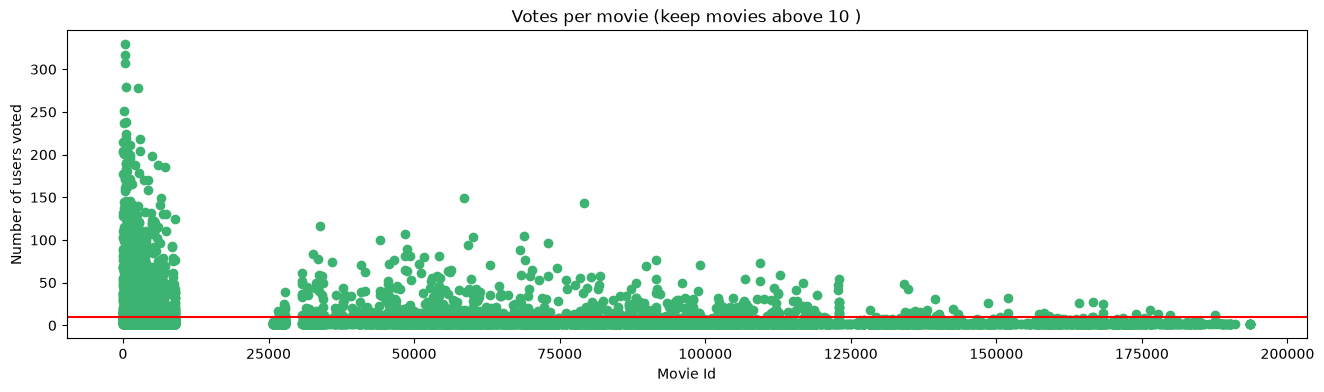

In [13]:
fig, ax = plt.subplots(1,1,figsize=(16,4))

plt.scatter(nb_user_votes.index, nb_user_votes, color= "mediumseagreen")
plt.axhline(y=10, color='r')
plt.xlabel('Movie Id')
plt.ylabel("Number of users voted")
plt.title("Votes per movie (keep movies above 10 )")
plt.show()

In [14]:
final_dataset  = final_dataset.loc[nb_user_votes[nb_user_votes > 10].index, :]
print("After movie filter", final_dataset.shape)

After movie filter (2121, 610)


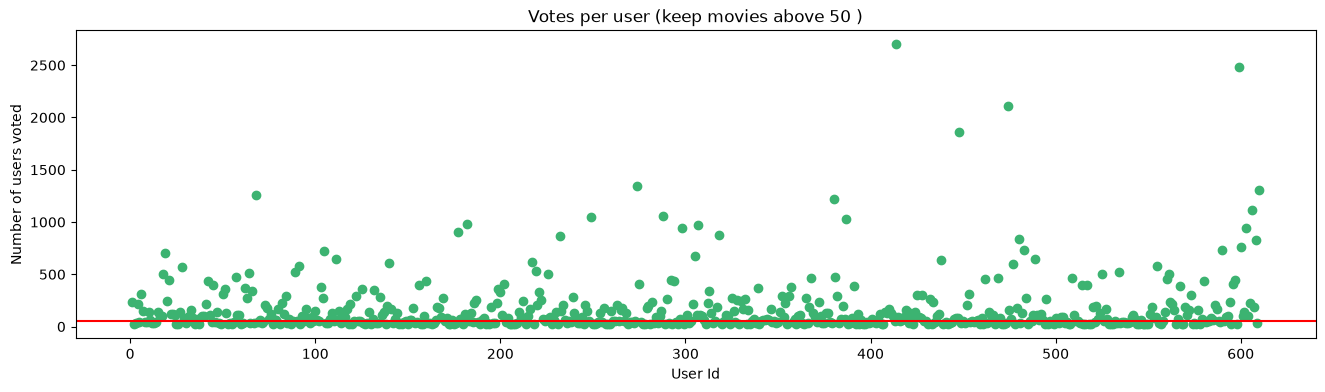

In [15]:
fig, ax = plt.subplots(1,1,figsize=(16,4))

plt.scatter(nb_movies_votes.index, nb_movies_votes, color= "mediumseagreen")
plt.axhline(y=50, color='r')
plt.xlabel('User Id')
plt.ylabel("Number of users voted")
plt.title("Votes per user (keep movies above 50 )")
plt.show()

In [19]:
final_dataset  = final_dataset.loc[:,nb_movies_votes[nb_movies_votes > 50].index]
print("After movie filter", final_dataset.shape)

After movie filter (2121, 378)


In [18]:
print("final_dataset index name:", final_dataset.index.name)
print("final_dataset shape:", final_dataset.shape)
print("nb_movies_votes index name:", nb_movies_votes.index.name)
print("how many wanted labels are actually present:",
      nb_movies_votes[nb_movies_votes > 50].index.isin(final_dataset.index).sum())


final_dataset index name: movieId
final_dataset shape: (2121, 610)
nb_movies_votes index name: userId
how many wanted labels are actually present: 173


In [20]:
sample = np.array([[0,0,3,0,0],
                    [4,0,0,0,2],
                    [0,0,0,0,1]])

sparsity = 1.0 - (np.count_nonzero(sample)/float(sample.size))
print(sparsity)

0.7333333333333334


In [23]:
print(csr_matrix(sparsity))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (1, 1)>
  Coords	Values
  (0, 0)	0.7333333333333334


In [26]:
csr_data = csr_matrix(final_dataset.values)
final_dataset = final_dataset.reset_index()
final_dataset.head()

userId,index,movieId,1,4,6,7,10,11,15,16,...,600,601,602,603,604,605,606,607,608,610
0,0,1,4.0,0.0,0.0,4.5,0.0,0.0,2.5,0.0,...,2.5,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,5.0
1,1,2,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0
2,2,3,4.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
3,3,5,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,...,2.5,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
4,4,6,4.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,3.0,4.0,3.0,0.0,0.0,0.0,0.0,5.0


## 1.5 Fit the KNN model

In [29]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity 

In [31]:
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20, n_jobs=-1)
knn.fit(csr_data)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


## 1.6 The recommendation function

Given a movie title, we:
1. Find its `movieId`, then its **row position** in `final_dataset`.
2. Ask KNN for the nearest neighbours.
3. Map the neighbour row positions back to titles.


In [32]:
def get_movie_recommendation(movie_name, n_movies_to_recommend=10):
    movie_list = movies[movies['title'].str.contains(movie_name, case=False)]
    if not len(movie_list):
        return "No movies found. Please check your input"

    movie_idx = movie_list.iloc[0]['movieId']
    movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]

    # ask the model for the nearest neighbours of this movie's row
    distances, indices = knn.kneighbors(
        csr_data[movie_idx], n_neighbors=n_movies_to_recommend + 1
    )

    rec_movie_indices = sorted(
        list(zip(indices.squeeze().tolist(), distances.squeeze().tolist())),
        key=lambda x: x[1]
    )[:0:-1]   # drop the movie itself (distance 0), reverse to ascending distance

    recommend_frame = []
    for val in rec_movie_indices:
        mid = final_dataset.iloc[val[0]]['movieId']
        idx = movies[movies['movieId'] == mid].index
        recommend_frame.append({
            'Title': movies.iloc[idx]['title'].values[0],
            'Distance': round(val[1], 3),
        })
    return pd.DataFrame(recommend_frame, index=range(1, n_movies_to_recommend + 1))


In [33]:
get_movie_recommendation('Iron Man')

,Title,Distance
1,X-Men: First Class (2011),0.0
2,Guardians of the Galaxy (2014),0.0
3,District 9 (2009),0.0
4,Sherlock Holmes (2009),0.0
5,Kung Fu Panda (2008),0.0
6,Watchmen (2009),0.0
7,Star Trek (2009),0.0
8,Iron Man 2 (2010),0.0
9,Avatar (2009),0.0
10,"Avengers, The (2012)",0.0


In [34]:
get_movie_recommendation('Toy Story')

,Title,Distance
1,Get Shorty (1995),0.667
2,"American President, The (1995)",0.654
3,Ace Ventura: When Nature Calls (1995),0.643
4,"Usual Suspects, The (1995)",0.605
5,Heat (1995),0.599
6,Seven (a.k.a. Se7en) (1995),0.597
7,GoldenEye (1995),0.550
8,Jumanji (1995),0.548
9,Babe (1995),0.539
10,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),0.535


In [35]:
get_movie_recommendation('Avengers')

,Title,Distance
1,"Haunting, The (1999)",0.0
2,Hidalgo (2004),0.0
3,Aeon Flux (2005),0.0
4,"Stepford Wives, The (2004)",0.0
5,Lemony Snicket's A Series of Unfortunate Event...,0.0
6,S.W.A.T. (2003),0.0
7,Bulletproof Monk (2003),0.0
8,Sister Act 2: Back in the Habit (1993),0.0
9,Thirteen Ghosts (a.k.a. Thir13en Ghosts) (2001),0.0
10,Reindeer Games (2000),0.0


In [36]:
get_movie_recommendation('Toy story')

,Title,Distance
1,Get Shorty (1995),0.667
2,"American President, The (1995)",0.654
3,Ace Ventura: When Nature Calls (1995),0.643
4,"Usual Suspects, The (1995)",0.605
5,Heat (1995),0.599
6,Seven (a.k.a. Se7en) (1995),0.597
7,GoldenEye (1995),0.550
8,Jumanji (1995),0.548
9,Babe (1995),0.539
10,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),0.535


---
# Part 2 — Content-Based Filtering (TF-IDF)

**Goal:** recommend movies that are *described* similarly — using their **genres** and **title** as text.

No ratings required, so **no cold-start problem** for new movies. The trade-off: it can only find
what's literally written in the metadata.

### The plan
1. Turn each movie into a **text document** ("Adventure Animation Comedy toy story").
2. Vectorise with **TF-IDF** (Term Frequency–Inverse Document Frequency).
3. Compute the **cosine similarity** between every pair of movies.
4. Write `recommend_content()`.


## 2.1 Build a text representation of each movie

Genres come as `Adventure|Animation|Children`. We'll convert the `|` to spaces and append the
lower-cased title, producing one "document" per movie.


In [40]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [41]:
mv = movies.copy()

# replace the pipe '|' in genres with a space
mv['genres_text'] = mv['genres'].str.replace('|', ' ', regex=False)

# lower-case the title
mv['title_text'] = mv['title'].str.lower()

# combine into a single text field
mv['combined_text'] = mv['genres_text'] + ' ' + mv['title_text']
mv[['title', 'combined_text']].head()


,title,combined_text
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy to...
1,Jumanji (1995),Adventure Children Fantasy jumanji (1995)
2,Grumpier Old Men (1995),Comedy Romance grumpier old men (1995)
3,Waiting to Exhale (1995),Comedy Drama Romance waiting to exhale (1995)
4,Father of the Bride Part II (1995),Comedy father of the bride part ii (1995)


## 2.2 What is TF-IDF? (intuition)

- **TF** (term frequency): how often a word appears in a document.
- **IDF** (inverse document frequency): how *rare* the word is across all documents.
- A word scores high when it's frequent **in this movie** but rare **overall** — i.e. it's
  *distinctive*. Common words like "the" get crushed; "animation" or "noir" get boosted.

`ngram_range=(1,2)` also captures two-word phrases ("science fiction").

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [43]:
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2)

# fit + transform the 'combined_text' column
tfidf_matrix = tfidf.fit_transform(mv['combined_text'])

print("TF-IDF matrix shape (movies x features):", tfidf_matrix.shape)
print("A few learned features:", tfidf.get_feature_names_out()[500:510])


TF-IDF matrix shape (movies x features): (9742, 5701)
A few learned features: ['best exotic' 'best friend' 'best man' 'beth' 'better' 'better living'
 'better tomorrow' 'betty' 'beverly' 'beverly hills']


## 2.3 Cosine similarity — done the memory-safe way

Cosine similarity = 1 when two TF-IDF vectors point the same direction (identical wording),
0 when they share no words.

> ⚠️ **A trap to avoid.** It's tempting to write `cosine_similarity(tfidf_matrix)` to get the full
> *movie × movie* matrix at once. With ~9,700 movies that's a `9742 × 9742` dense float64 array =
> **~720 MB** — it can freeze or crash a laptop. On the full MovieLens it's hopeless.
>
> Instead we compute similarities **one query at a time**: when the user asks about *one* movie,
> we compare *its* vector against all rows. That's a single cheap `(1 × n)` operation.

In [44]:
# map movieId -> row position so we can look movies up fast
indices = pd.Series(mv.index, index=mv['movieId'])

def similarity_for(idx):
    """Cosine similarity of movie at row `idx` vs every movie. Returns a 1-D array."""
    # compare ONE row (tfidf_matrix[idx]) against the whole matrix, then flatten
    return cosine_similarity(tfidf_matrix[idx], tfidf_matrix).ravel()

# sanity check: a movie is perfectly similar to itself (score ~1.0)
print("self-similarity of Toy Story:", round(similarity_for(indices[1])[indices[1]], 3))


self-similarity of Toy Story: 1.0


## 2.4 The content recommender

In [45]:
def get_similar_movies(movie_id, n=10):
    if movie_id not in indices:
        return "Movie not found."

    idx = indices[movie_id]
    sims = similarity_for(idx)                 # 1-D similarity vector
    sim_scores = list(enumerate(sims))

    # sort by similarity score, descending
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # drop the movie itself (position 0) and keep the next n
    sim_scores = sim_scores[1:n + 1]

    movie_indices = [i for i, _ in sim_scores]
    scores = [round(s, 3) for _, s in sim_scores]

    result = mv.iloc[movie_indices][['movieId', 'title', 'genres']].copy()
    result['similarity_score'] = scores
    return result


In [46]:
get_similar_movies(1,10)

,movieId,title,genres,similarity_score
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.802
7355,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.642
1706,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.485
9430,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.482
12,13,Balto (1995),Adventure|Animation|Children,0.448
209,243,Gordy (1995),Children|Comedy|Fantasy,0.429
6194,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,0.429
7917,95311,Presto (2008),Animation|Children|Comedy|Fantasy,0.418
3568,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.414
6205,45431,Over the Hedge (2006),Adventure|Animation|Children|Comedy,0.410


In [47]:
get_similar_movies(3,10)

,movieId,title,genres,similarity_score
2581,3450,Grumpy Old Men (1993),Comedy,0.827
9048,141820,Old Men: Robbers (1971),Comedy,0.682
6613,55820,No Country for Old Men (2007),Crime|Drama,0.594
8323,107408,Only Old Men Are Going to Battle (V boy idut o...,Comedy|Drama|War,0.559
35,39,Clueless (1995),Comedy|Romance,0.485
152,180,Mallrats (1995),Comedy|Romance,0.485
529,618,Two Much (1995),Comedy|Romance,0.485
6469,52715,Kickin It Old Skool (2007),Comedy,0.448
17,18,Four Rooms (1995),Comedy,0.344
3758,5241,Seems Like Old Times (1980),Comedy|Romance,0.329


## 2.5 Personalised recommendations from content

We can build a **user profile** by averaging the similarity vectors of the movies they rated,
weighted by their rating, then recommend the highest-scoring unwatched movies.


In [50]:
def user_recommendations(user_id, n=10):
    user_ratings = ratings[ratings['userId'] == user_id]
    watched_movies = user_ratings['movieId'].values

    scores = np.zeros(len(mv))
    weight_sum = 0.0

    for _, row in user_ratings.iterrows():
        movie_id, rating = row['movieId'], row['rating']
        if movie_id in indices:
            idx = indices[movie_id]
            # add this movie's similarity row, weighted by the rating
            scores += similarity_for(idx) * rating
            weight_sum += rating

    if weight_sum > 0:
        scores /= weight_sum

    # don't recommend movies the user already watched
    watched_idx = [indices[m] for m in watched_movies if m in indices]
    scores[watched_idx] = -np.inf

    top_idx = np.argsort(scores)[::-1][:n]
    result = mv.iloc[top_idx][['movieId', 'title', 'genres']].copy()
    result['score'] = np.round(scores[top_idx], 3)
    return result


In [53]:
user_recommendations(173, 10)


,movieId,title,genres,score
264,304,Roommates (1995),Comedy|Drama,0.169
85,96,In the Bleak Midwinter (1995),Comedy|Drama,0.169
309,351,"Corrina, Corrina (1994)",Comedy|Drama|Romance,0.162
319,361,It Could Happen to You (1994),Comedy|Drama|Romance,0.162
4569,6788,Angie (1994),Comedy|Drama|Romance,0.162
4682,6992,Guarding Tess (1994),Comedy|Drama,0.152
310,352,Crooklyn (1994),Comedy|Drama,0.152
391,450,With Honors (1994),Comedy|Drama,0.152
414,476,"Inkwell, The (1994)",Comedy|Drama,0.152
35,39,Clueless (1995),Comedy|Romance,0.143


---
# Part 3 — Compare, combine, and evaluate

## 3.1 Side-by-side comparison

Pick a movie that exists in **both** worlds and compare what each method returns.


In [54]:
TITLE = "Toy Story"
movie_id = movies[movies['title'].str.contains(TITLE, case=False)].iloc[0]['movieId']

print("=== Collaborative (KNN on ratings) ===")
display(get_movie_recommendation(TITLE))

print("=== Content-based (TF-IDF on genres+title) ===")
display(get_similar_movies(movie_id))


=== Collaborative (KNN on ratings) ===


,Title,Distance
1,Get Shorty (1995),0.667
2,"American President, The (1995)",0.654
3,Ace Ventura: When Nature Calls (1995),0.643
4,"Usual Suspects, The (1995)",0.605
5,Heat (1995),0.599
6,Seven (a.k.a. Se7en) (1995),0.597
7,GoldenEye (1995),0.550
8,Jumanji (1995),0.548
9,Babe (1995),0.539
10,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),0.535


=== Content-based (TF-IDF on genres+title) ===


,movieId,title,genres,similarity_score
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.802
7355,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.642
1706,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.485
9430,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.482
12,13,Balto (1995),Adventure|Animation|Children,0.448
209,243,Gordy (1995),Children|Comedy|Fantasy,0.429
6194,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,0.429
7917,95311,Presto (2008),Animation|Children|Comedy|Fantasy,0.418
3568,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.414
6205,45431,Over the Hedge (2006),Adventure|Animation|Children|Comedy,0.410
